In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [ ]:
# DataFrame Info
# Columns:
# - Date:       Current date  -  Unique: 7465
# - Expiry:     Date of expiry  -> increases for newer dates                        [1996-01-04 - 2025-09-08]
# - Texp:       Time to expiry in years (difference between 'Date' and 'Expiry') number of expiries    [6, 528]
# - Strike:     Strike price
# - Bid:        Bid-price       -> has NA values ~9% -> Data seems clear enough to  ignore the NaN values
# - Ask:        Ask-price       
# - Fwd:        Forward-price
# - CallMid:    IV in bps?

In [44]:
import os

dfs = []
path = os.path.join(os.getcwd(), "data/csv")
for file in tqdm(os.listdir(path)):
    abspath = os.path.join(path, file)
    
    df = pd.read_csv(abspath)
    
    df["Expiry"] = df["Expiry"].astype(str)
    df["Expiry"] = pd.to_datetime(df["Expiry"])
    
    df["Date"] = pd.to_datetime(file.removesuffix(".csv"))

    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.to_parquet("data/final.parquet")
df.head()

100%|██████████| 7465/7465 [00:54<00:00, 137.36it/s]


,Expiry,Texp,Strike,Bid,Ask,Fwd,CallMid,Date
0,1996-01-20,0.043806,400,NaN,0.748694,616.91877,NaN,1996-01-04
1,1996-01-20,0.043806,525,NaN,0.331098,616.91877,NaN,1996-01-04
2,1996-01-20,0.043806,535,NaN,0.296718,616.91877,NaN,1996-01-04
3,1996-01-20,0.043806,540,0.256724,0.279628,616.91877,77.01841,1996-01-04
4,1996-01-20,0.043806,545,0.240831,0.262591,616.91877,72.01841,1996-01-04


In [2]:
df = pd.read_parquet("data/final.parquet")
df = df.loc[(df["Date"] >= "2000-01-01") & (df["Date"] <= "2024-12-31")]

df["z"] = np.log(df["Strike"] / df["Fwd"])
df["w"] = (df["CallMid"] / 10_000) ** 2 * df["Texp"]

df = df[["Date", "Texp", "z", "w"]]
df.to_parquet("data/ivdata.parquet")

df.head()

,Date,Texp,z,w
219043,2000-01-03,0.052019,-0.400915,NaN
219044,2000-01-03,0.052019,-0.350905,0.000097
219045,2000-01-03,0.052019,-0.326807,0.000086
219046,2000-01-03,0.052019,-0.303277,0.000076
219047,2000-01-03,0.052019,-0.280287,0.000066


In [4]:
df = pd.read_parquet("data/final.parquet")
df = df.loc[(df["Date"] >= "2000-01-01") & (df["Date"] <= "2024-12-31")]

# times = (df["Expiry"] - df["Date"]).dt.days / df["Texp"]
# plt.hist(times, bins=1000)

In [48]:
len(df)

18752333

In [5]:
predict_expiry = df["Date"] + pd.to_timedelta(df["Texp"] * 365, unit='D')
predict_error = predict_expiry - df["Expiry"]
pct_pred_err = predict_error.dt.days / (df["Expiry"] -  df["Date"]).dt.days

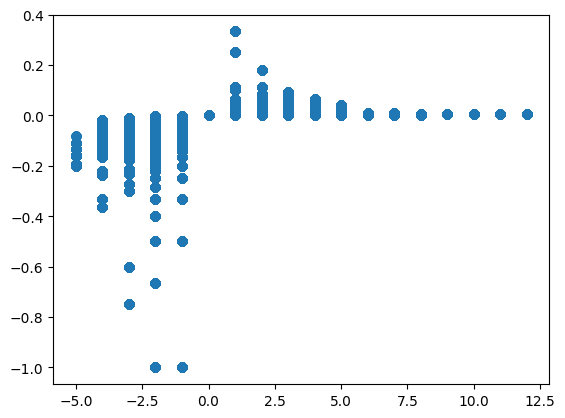

In [6]:
# pct_pred_err.hist(bins=100)
plt.scatter(predict_error.dt.days, pct_pred_err)
# df.loc[predict_error.dt.days > 7, "Texp"].hist(bins=100)

In [24]:
# mask = (-1 < predict_error.dt.days) & (predict_error.dt.days < 1)
# plt.scatter(predict_error.dt.days[~mask], pct_pred_err[~mask])
df[(pct_pred_err < -0.5) & (abs(predict_error.dt.days) > 2)]

,Expiry,Texp,Strike,Bid,Ask,Fwd,CallMid,Date
15807280,2023-09-05,0.004,1200,NaN,5.981498,4515.354041,NaN,2023-09-01
15807281,2023-09-05,0.004,1400,NaN,5.301022,4515.354041,NaN,2023-09-01
15807282,2023-09-05,0.004,1600,NaN,4.712940,4515.354041,NaN,2023-09-01
15807283,2023-09-05,0.004,1800,NaN,4.194809,4515.354041,NaN,2023-09-01
15807284,2023-09-05,0.004,2000,NaN,3.731392,4515.354041,NaN,2023-09-01
...,...,...,...,...,...,...,...,...
18736615,2024-12-02,0.008,7000,NaN,0.532025,6000.968417,NaN,2024-11-27
18736616,2024-12-02,0.008,7200,NaN,0.620772,6000.968417,NaN,2024-11-27
18736617,2024-12-02,0.008,7400,NaN,0.706076,6000.968417,NaN,2024-11-27
18736618,2024-12-02,0.008,7600,NaN,0.788278,6000.968417,NaN,2024-11-27


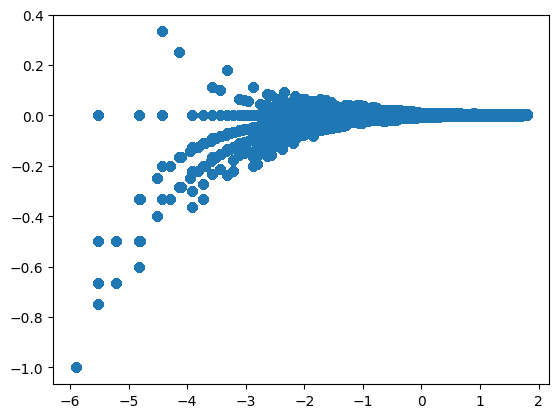

In [25]:
plt.scatter(np.log(df["Texp"]), pct_pred_err)

In [ ]:
def f(g):
    date, texp = g.name
    diff = (g["Expiry"] - date).d
    
df.groupby(["Date", "Texp"], as_index=False).filter(f)

np.int64(18327431)

In [42]:
%matplotlib qt
F = (abs(predict_error.dt.days) > 1)
filt = df[F]

plt.scatter((filt["Texp"]) * 365, abs(pct_pred_err[F]))
plt.plot([0, 365], [0, 1])

In [44]:
filt

,Expiry,Texp,Strike,Bid,Ask,Fwd,CallMid,Date
322673,2001-09-22,0.046543,800,NaN,0.579550,1131.014969,NaN,2001-09-04
322674,2001-09-22,0.046543,900,0.413894,0.457778,1131.014969,231.265256,2001-09-04
322675,2001-09-22,0.046543,950,0.367354,0.410953,1131.014969,181.640685,2001-09-04
322676,2001-09-22,0.046543,975,0.351042,0.380314,1131.014969,156.991085,2001-09-04
322677,2001-09-22,0.046543,995,0.336591,0.357908,1131.014969,137.441600,2001-09-04
...,...,...,...,...,...,...,...,...
18971371,2029-12-21,5.000000,9000,0.135862,0.141845,7085.357235,311.814001,2024-12-31
18971372,2029-12-21,5.000000,9200,0.133330,0.139395,7085.357235,265.811735,2024-12-31
18971373,2029-12-21,5.000000,9400,0.131012,0.137196,7085.357235,225.692752,2024-12-31
18971374,2029-12-21,5.000000,9600,0.128866,0.135204,7085.357235,190.831170,2024-12-31


In [46]:
0.046543*365, 18/365

(16.988195, 0.049315068493150684)

In [ ]:
def f(g):
    date, texp = g.name
    diff = (g["Expiry"] - date).d
    
df.groupby(["Date", "Texp"], as_index=False).filter(f)

np.int64(18327431)